In [2]:
import json
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


In [3]:
entsoe_timeseries_df = pd.read_csv("../datasets/entsoe.csv", index_col=0, parse_dates=True)
with open("../metadata_wind_farms.json") as f:
    wind_farms_metadata = json.load(f)["wind_farms"]

In [4]:
wind_farm_id_list = [wf["id"] for wf in wind_farms_metadata if wf.get("offshore_data_available") is True]
print(wind_farm_id_list)

['Borssele_12', 'Borssele_34', 'Gemini', 'Hollandse_Kust_Zuid', 'Hollandse_Kust_Noord']


In [5]:
df_nearest_KNMI_stations = {}
for wind_farm in wind_farms_metadata:
    station = wind_farm.get("nearest_KNMI_station")
    try:
        df = pd.read_csv("../datasets/knmi_"+station+".csv",  index_col=0, parse_dates=True)
        df_nearest_KNMI_stations[wind_farm['id']] = df
    except:
        print(f"No file found for station {station} needed for {wind_farm['id']}")

No file found for station None needed for Windfarm_Princess_Amalia
No file found for station None needed for OWEZ


In [6]:
df_nearest_KNMI_stations["Borssele_12"]

,Station,Station_ID,Source_Period,Source_File,wind_direction_deg,wind_direction_interpolated_deg,wind_dir_sin,wind_dir_cos,wind_speed_ms,wind_speed_10min_ms,...,min_temp_10cm_c,dew_point_c,sunshine_duration_h,global_radiation_j_cm2,precip_duration_h,precipitation_mm,pressure_hpa,visibility_code,cloud_cover_octants,humidity_pct
timestamp,,,,,,,,,,,,,,,,,,,,,
2015-01-01 00:00:00,Vlissingen,310,2011-2020,Vlissingen_310_2011-2020.txt,200.0,200.0,-0.342020,-9.396926e-01,7.0,7.0,...,1.400000,0.9,0.0,0,0.0,0.0,1034.8,59.0,0.0,86
2015-01-01 01:00:00,Vlissingen,310,2011-2020,Vlissingen_310_2011-2020.txt,210.0,210.0,-0.500000,-8.660254e-01,7.0,7.0,...,1.400000,0.3,0.0,0,0.0,0.0,1034.9,59.0,0.0,85
2015-01-01 02:00:00,Vlissingen,310,2011-2020,Vlissingen_310_2011-2020.txt,200.0,200.0,-0.342020,-9.396926e-01,7.0,8.0,...,1.400000,0.3,0.0,0,0.0,0.0,1033.8,60.0,0.0,84
2015-01-01 03:00:00,Vlissingen,310,2011-2020,Vlissingen_310_2011-2020.txt,210.0,210.0,-0.500000,-8.660254e-01,7.0,6.0,...,1.400000,-0.1,0.0,0,0.0,0.0,1035.1,61.0,0.0,84
2015-01-01 04:00:00,Vlissingen,310,2011-2020,Vlissingen_310_2011-2020.txt,200.0,200.0,-0.342020,-9.396926e-01,7.0,8.0,...,1.400000,0.0,0.0,0,0.0,0.0,1034.7,60.0,0.0,85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-01 19:00:00,Vlissingen,310,2021-2030,Vlissingen_310_2021-2030.txt,280.0,280.0,-0.984808,1.736482e-01,3.0,2.0,...,17.466667,13.4,0.2,6,0.0,0.0,1012.5,73.0,8.0,79
2026-06-01 20:00:00,Vlissingen,310,2021-2030,Vlissingen_310_2021-2030.txt,270.0,270.0,-1.000000,-1.836970e-16,3.0,4.0,...,17.050000,12.9,0.0,0,0.0,0.0,1012.1,77.0,8.0,75
2026-06-01 21:00:00,Vlissingen,310,2021-2030,Vlissingen_310_2021-2030.txt,150.0,150.0,0.500000,-8.660254e-01,2.0,2.0,...,16.633333,14.3,0.0,0,0.0,0.0,1011.4,70.0,8.0,83


In [7]:
df_borssele_12 = pd.read_csv("../datasets/offshore_Borssele_12.csv")
df_borssele_34 = pd.read_csv("../datasets/offshore_Borssele_34.csv")
df_gemini = pd.read_csv("../datasets/offshore_Gemini.csv")
df_h_k_zuid = pd.read_csv("../datasets/offshore_Hollandse_Kust_Zuid.csv")
df_h_k_noord = pd.read_csv("../datasets/offshore_Hollandse_Kust_Noord.csv")

datasets = {
    'Borssele 1&2': df_borssele_12,
    'Borssele 3&4': df_borssele_34,
    'Gemini':       df_gemini,
    'Hollandse Kust Zuid': df_h_k_zuid,
    'Hollandse Kust Noord': df_h_k_noord,
}

C:\Users\lackn\AppData\Local\Temp\ipykernel_23328\865983651.py:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


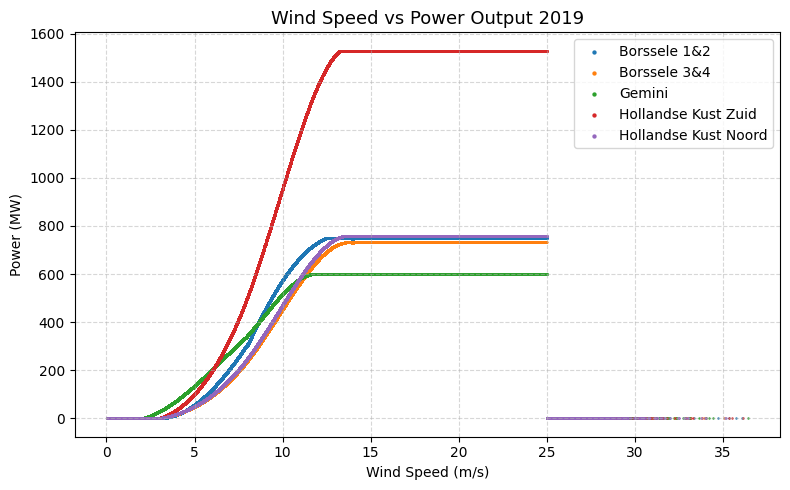

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

for label, df in datasets.items():
    ax.scatter(df['Scaled_Windspeed'], df['Power'], alpha=1, s=0.5, label=label)

ax.set_title('Wind Speed vs Power Output 2019', fontsize=13)
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Power (MW)')
ax.legend(markerscale=3)   # markerscale makes the tiny dots visible in the legend
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [9]:
def logistic_piece(v, alpha, beta, gamma, delta):
    return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)

def double_logistic(v, alpha1, beta1, gamma1, delta1, alpha2, beta2, gamma2, delta2):
    return (logistic_piece(v, alpha1, beta1, gamma1, delta1) +
            logistic_piece(v, alpha2, beta2, gamma2, delta2))

Fitted parameters:
alpha1=217.722, beta1=0.169, gamma1=0.731, delta1=3.511
alpha2=535.733, beta2=1.406, gamma2=1.084, delta2=9.621


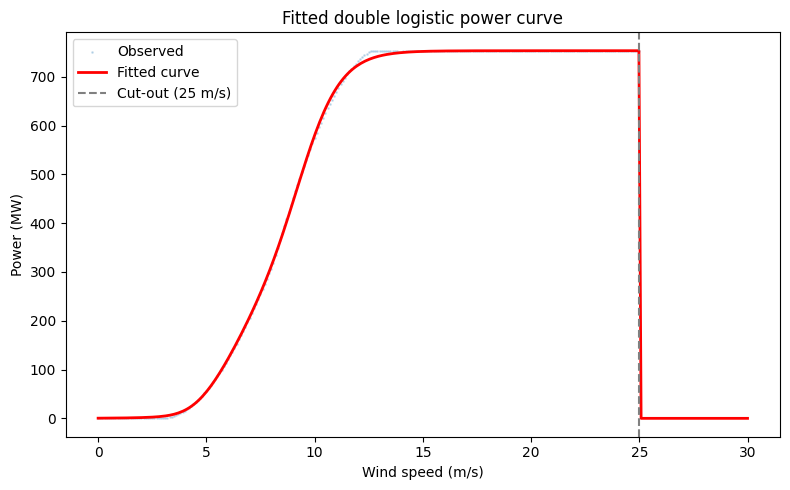

In [10]:
df = df_borssele_12

fit_df = df[(df["Turn_off"] == 1) & (df["Scaled_Windspeed"] > 0)].copy()

fit_df["v_bin"] = fit_df["Scaled_Windspeed"].round(1)
binned = fit_df.groupby("v_bin")["Power"].mean().reset_index()

v = binned["v_bin"].values
p = binned["Power"].values

p0 = [
    400, 1.0, 0.5, 6.0,
    330, 1.0, 0.5, 11.0
]

popt, pcov = curve_fit(double_logistic, v, p, p0=p0, bounds=(
    [0, 0.01, 0, 0, 0, 0.01, 0, 0],
    [np.inf, 10, 10, 30, np.inf, 10, 10, 30]
), method='dogbox', maxfev=20000)

print("Fitted parameters:")
print(f"alpha1={popt[0]:.3f}, beta1={popt[1]:.3f}, gamma1={popt[2]:.3f}, delta1={popt[3]:.3f}")
print(f"alpha2={popt[4]:.3f}, beta2={popt[5]:.3f}, gamma2={popt[6]:.3f}, delta2={popt[7]:.3f}")

# --- apply cut-out at 25 m/s ---
v_range = np.linspace(0, 30, 300)
p_fitted = np.where(
    v_range <= 25,
    double_logistic(v_range, *popt),
    0
)

# --- plot ---
plt.figure(figsize=(8, 5))
plt.scatter(v, p, s=1, alpha=0.2, label="Observed")
plt.plot(v_range, p_fitted, color="red", linewidth=2, label="Fitted curve")
plt.axvline(25, color="gray", linestyle="--", label="Cut-out (25 m/s)")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power (MW)")
plt.title("Fitted double logistic power curve")
plt.legend()
plt.tight_layout()
plt.show()

Fitted parameters:
alpha1=326.769, beta1=0.742, gamma1=0.719, delta1=7.032
alpha2=405.992, beta2=2.492, gamma2=1.429, delta2=11.462


C:\Users\lackn\AppData\Local\Temp\ipykernel_23328\784927076.py:2: RuntimeWarning: overflow encountered in power
  return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)


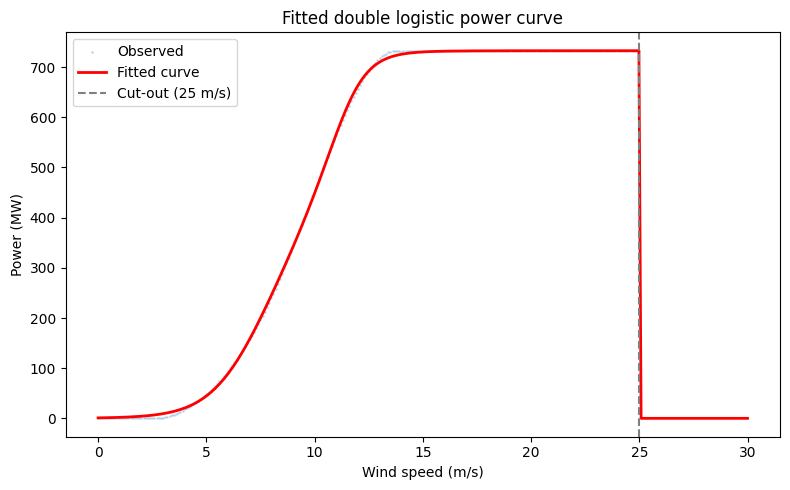

In [11]:
df = df_borssele_34

fit_df = df[(df["Turn_off"] == 1) & (df["Scaled_Windspeed"] > 0)].copy()

fit_df["v_bin"] = fit_df["Scaled_Windspeed"].round(1)
binned = fit_df.groupby("v_bin")["Power"].mean().reset_index()

v = binned["v_bin"].values
p = binned["Power"].values

p0 = [
    400, 1.0, 0.5, 6.0,
    330, 1.0, 0.5, 11.0
]

popt, pcov = curve_fit(double_logistic, v, p, p0=p0, bounds=([0, 0.01, 0, 0, 0, 0.01, 0, 0], [np.inf, 10, 10, 30, np.inf, 10, 10, 30]), method='dogbox')

print("Fitted parameters:")
print(f"alpha1={popt[0]:.3f}, beta1={popt[1]:.3f}, gamma1={popt[2]:.3f}, delta1={popt[3]:.3f}")
print(f"alpha2={popt[4]:.3f}, beta2={popt[5]:.3f}, gamma2={popt[6]:.3f}, delta2={popt[7]:.3f}")

# --- apply cut-out at 25 m/s ---
v_range = np.linspace(0, 30, 300)
p_fitted = np.where(
    v_range <= 25,
    double_logistic(v_range, *popt),
    0
)

# --- plot ---
plt.figure(figsize=(8, 5))
plt.scatter(v, p, s=1, alpha=0.2, label="Observed")
plt.plot(v_range, p_fitted, color="red", linewidth=2, label="Fitted curve")
plt.axvline(25, color="gray", linestyle="--", label="Cut-out (25 m/s)")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power (MW)")
plt.title("Fitted double logistic power curve")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\lackn\AppData\Local\Temp\ipykernel_23328\784927076.py:2: RuntimeWarning: overflow encountered in power
  return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)


Fitted parameters:
alpha1=603.831, beta1=1.359, gamma1=0.712, delta1=7.971
alpha2=0.000, beta2=0.010, gamma2=1.881, delta2=12.574


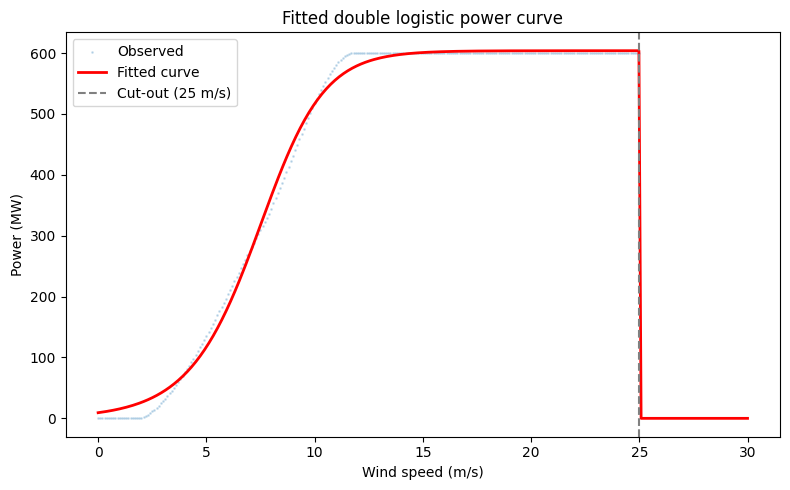

In [12]:
df = df_gemini

fit_df = df[(df["Turn_off"] == 1) & (df["Scaled_Windspeed"] > 0)].copy()

fit_df["v_bin"] = fit_df["Scaled_Windspeed"].round(1)
binned = fit_df.groupby("v_bin")["Power"].mean().reset_index()

v = binned["v_bin"].values
p = binned["Power"].values

p0 = [
    p.max(), 1.0, 0.7, 8.0,
    p.max(), 2.5, 1.4, 11.0
]

popt, pcov = curve_fit(
    double_logistic,
    v, p,
    p0=p0,
    bounds=(
        [0, 0.01, 0, 0, 0, 0.01, 0, 0],
        [np.inf, 10, 10, 30, np.inf, 10, 10, 30]
    ),
    method='dogbox',
    maxfev=20000
)

print("Fitted parameters:")
print(f"alpha1={popt[0]:.3f}, beta1={popt[1]:.3f}, gamma1={popt[2]:.3f}, delta1={popt[3]:.3f}")
print(f"alpha2={popt[4]:.3f}, beta2={popt[5]:.3f}, gamma2={popt[6]:.3f}, delta2={popt[7]:.3f}")

# --- apply cut-out at 25 m/s ---
v_range = np.linspace(0, 30, 300)
p_fitted = np.where(
    v_range <= 25,
    double_logistic(v_range, *popt),
    0
)

# --- plot ---
plt.figure(figsize=(8, 5))
plt.scatter(v, p, s=1, alpha=0.2, label="Observed")
plt.plot(v_range, p_fitted, color="red", linewidth=2, label="Fitted curve")
plt.axvline(25, color="gray", linestyle="--", label="Cut-out (25 m/s)")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power (MW)")
plt.title("Fitted double logistic power curve")
plt.legend()
plt.tight_layout()
plt.show()

Fitted parameters:
alpha1=338.947, beta1=0.742, gamma1=0.718, delta1=7.029
alpha2=421.362, beta2=2.492, gamma2=1.429, delta2=11.462


C:\Users\lackn\AppData\Local\Temp\ipykernel_23328\784927076.py:2: RuntimeWarning: overflow encountered in power
  return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)


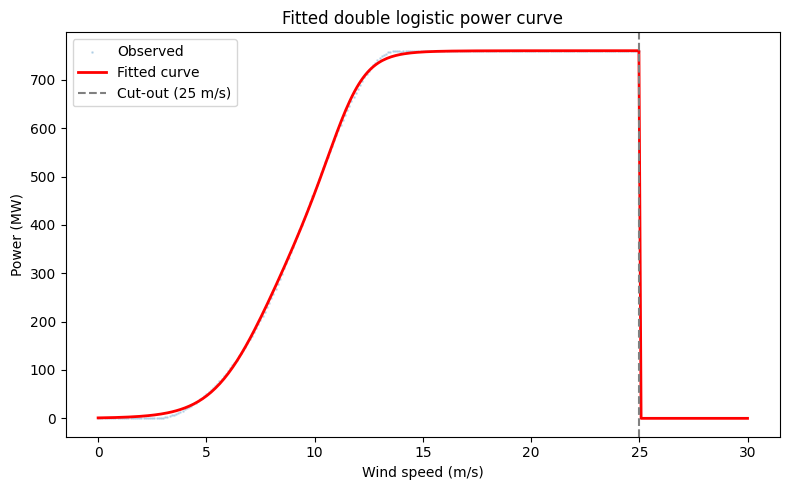

In [13]:
df = df_h_k_noord

fit_df = df[(df["Turn_off"] == 1) & (df["Scaled_Windspeed"] > 0)].copy()

fit_df["v_bin"] = fit_df["Scaled_Windspeed"].round(1)
binned = fit_df.groupby("v_bin")["Power"].mean().reset_index()

v = binned["v_bin"].values
p = binned["Power"].values

p0 = [
    400, 1.0, 0.5, 6.0,
    330, 1.0, 0.5, 11.0
]

popt, pcov = curve_fit(
    double_logistic,
    v, p,
    p0=p0,
    bounds=(
        [0, 0.01, 0, 0, 0, 0.01, 0, 0],
        [np.inf, 10, 10, 30, np.inf, 10, 10, 30]
    ),
    method='dogbox',
    maxfev=20000
)

print("Fitted parameters:")
print(f"alpha1={popt[0]:.3f}, beta1={popt[1]:.3f}, gamma1={popt[2]:.3f}, delta1={popt[3]:.3f}")
print(f"alpha2={popt[4]:.3f}, beta2={popt[5]:.3f}, gamma2={popt[6]:.3f}, delta2={popt[7]:.3f}")

# --- apply cut-out at 25 m/s ---
v_range = np.linspace(0, 30, 300)
p_fitted = np.where(
    v_range <= 25,
    double_logistic(v_range, *popt),
    0
)

# --- plot ---
plt.figure(figsize=(8, 5))
plt.scatter(v, p, s=1, alpha=0.2, label="Observed")
plt.plot(v_range, p_fitted, color="red", linewidth=2, label="Fitted curve")
plt.axvline(25, color="gray", linestyle="--", label="Cut-out (25 m/s)")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power (MW)")
plt.title("Fitted double logistic power curve")
plt.legend()
plt.tight_layout()
plt.show()

Fitted parameters:
alpha1=691.469, beta1=0.775, gamma1=0.732, delta1=7.125
alpha2=840.127, beta2=2.675, gamma2=1.519, delta2=11.489


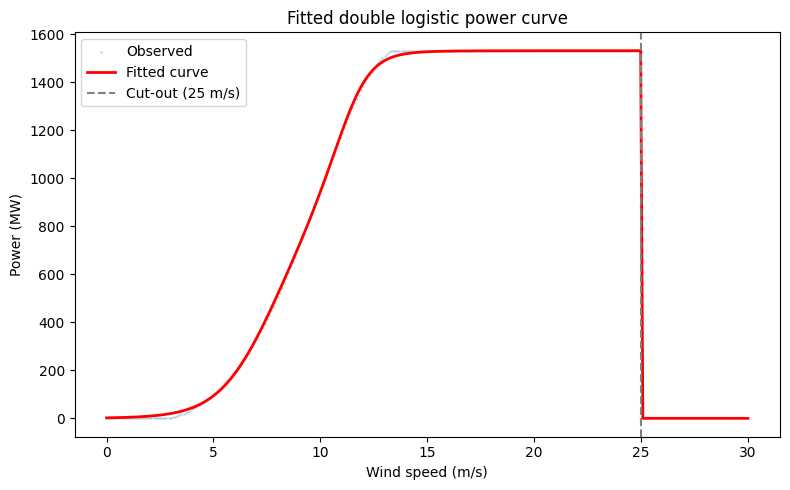

In [14]:
df = df_h_k_zuid

fit_df = df[(df["Turn_off"] == 1) & (df["Scaled_Windspeed"] > 0)].copy()

fit_df["v_bin"] = fit_df["Scaled_Windspeed"].round(1)
binned = fit_df.groupby("v_bin")["Power"].mean().reset_index()

v = binned["v_bin"].values
p = binned["Power"].values

p0 = [
    p.max(), 1.0, 0.5, 6.0,
    330, 1.0, 0.5, 11.0
]

popt, pcov = curve_fit(
    double_logistic,
    v, p,
    p0=p0,
    bounds=(
        [0, 0.01, 0, 0, 0, 0.01, 0, 0],
        [np.inf, 10, 10, 30, np.inf, 10, 10, 30]
    ),
    method='dogbox',
    maxfev=20000
)

print("Fitted parameters:")
print(f"alpha1={popt[0]:.3f}, beta1={popt[1]:.3f}, gamma1={popt[2]:.3f}, delta1={popt[3]:.3f}")
print(f"alpha2={popt[4]:.3f}, beta2={popt[5]:.3f}, gamma2={popt[6]:.3f}, delta2={popt[7]:.3f}")

# --- apply cut-out at 25 m/s ---
v_range = np.linspace(0, 30, 300)
p_fitted = np.where(
    v_range <= 25,
    double_logistic(v_range, *popt),
    0
)

# --- plot ---
plt.figure(figsize=(8, 5))
plt.scatter(v, p, s=1, alpha=0.2, label="Observed")
plt.plot(v_range, p_fitted, color="red", linewidth=2, label="Fitted curve")
plt.axvline(25, color="gray", linestyle="--", label="Cut-out (25 m/s)")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power (MW)")
plt.title("Fitted double logistic power curve")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
def predict_power(wind_speed, popt, cut_out=25.0):
    p = double_logistic(wind_speed, *popt)
    p = np.where(wind_speed >= cut_out, 0, p)  # cut-out
    p = np.where(wind_speed < 3, 0, p)
    p = np.maximum(p, 0)
    return p

In [16]:
results = []

configs = {
    'Borssele 1&2':       df_borssele_12,
    'Borssele 3&4':       df_borssele_34,
    'Gemini':             df_gemini,
    'Hollandse Kust Zuid': df_h_k_zuid,
    'Hollandse Kust Noord': df_h_k_noord,
}

for name, df in configs.items():
    fit_df = df[(df["Turn_off"] == 1) & (df["Scaled_Windspeed"] > 0)].copy()
    fit_df["v_bin"] = fit_df["Scaled_Windspeed"].round(1)
    binned = fit_df.groupby("v_bin")["Power"].mean().reset_index()

    v = binned["v_bin"].values
    p = binned["Power"].values

    popt, _ = curve_fit(
        double_logistic, v, p,
        p0=[p.max(), 3.0, 0.3, 8.0, 0, 5.0, 0.5, 25.0],
        bounds=([0, 0.01, 0, 0, 0, 0.01, 0, 0],
                [np.inf, 10, 10, 30, np.inf, 10, 10, 30]),
        method='dogbox',
        maxfev=20000
    )

    results.append({
        'farm':   name,
        'alpha1': popt[0], 'beta1': popt[1],
        'gamma1': popt[2], 'delta1': popt[3],
        'alpha2': popt[4], 'beta2': popt[5],
        'gamma2': popt[6], 'delta2': popt[7],
    })

df_params = pd.DataFrame(results).set_index('farm')
print(df_params)

                           alpha1     beta1    gamma1     delta1    alpha2  \
farm                                                                         
Borssele 1&2           754.924637  1.344129  0.854407   8.955523  0.000000   
Borssele 3&4           735.101074  1.614197  0.825675  10.094552  0.007173   
Gemini                 603.830906  1.358995  0.711701   7.971081  0.000000   
Hollandse Kust Zuid   1536.436848  1.662283  0.844736  10.111295  0.860993   
Hollandse Kust Noord   762.737574  1.614138  0.825613  10.094579  2.018209   

                        beta2    gamma2     delta2  
farm                                                
Borssele 1&2          5.00000  0.500000  25.000000  
Borssele 3&4          0.01000  0.112066  12.195654  
Gemini                5.00000  0.500000  25.000000  
Hollandse Kust Zuid   0.02129  0.000000  26.807560  
Hollandse Kust Noord  0.01000  0.001573  29.274198  


In [17]:
df_predicted = pd.DataFrame(index=df_nearest_KNMI_stations["Borssele_12"].index)
windspeed_scaling_for_platform_height = 1.034

station_map = {
    'Borssele 1&2':        'Borssele_12',
    'Borssele 3&4':        'Borssele_34',
    'Gemini':              'Gemini',
    'Hollandse Kust Zuid': 'Hollandse_Kust_Zuid',
    'Hollandse Kust Noord':'Hollandse_Kust_Noord',
}

df_predicted = pd.concat(
    {
        col_name: pd.Series(
            predict_power(
                df_nearest_KNMI_stations[col_name]["wind_speed_ms"].values * windspeed_scaling_for_platform_height,
                df_params.loc[farm_name, ['alpha1','beta1','gamma1','delta1',
                                           'alpha2','beta2','gamma2','delta2']].values
            ),
            index=df_nearest_KNMI_stations[col_name].index
        )
        for farm_name, col_name in station_map.items()
    },
    axis=1
)

df_predicted["Total"] = df_predicted.sum(axis=1)
df_predicted.index.name = "timestamp"

In [18]:
# parse commissioned dates from metadata
commissioned_dates = {
    wf["id"]: pd.to_datetime(wf["commissioned"], dayfirst=True)
    for wf in wind_farms_metadata
    if "commissioned" in wf
}

windspeed_scaling_for_platform_height = 1.034

df_predicted = pd.concat(
    {
        col_name: pd.Series(
            predict_power(
                station_df.loc[station_df.index >= commissioned_dates.get(col_name, station_df.index.min()), "wind_speed_ms"].values * windspeed_scaling_for_platform_height,
                df_params.loc[farm_name, ['alpha1','beta1','gamma1','delta1',
                                           'alpha2','beta2','gamma2','delta2']].values
            ),
            index=station_df.loc[station_df.index >= commissioned_dates.get(col_name, station_df.index.min())].index
        )
        for farm_name, col_name in station_map.items()
        for station_df in [df_nearest_KNMI_stations[col_name]]
    },
    axis=1, sort=True
)

df_predicted["Total"] = df_predicted.sum(axis=1)
df_predicted.index.name = "timestamp"

<Axes: xlabel='timestamp'>

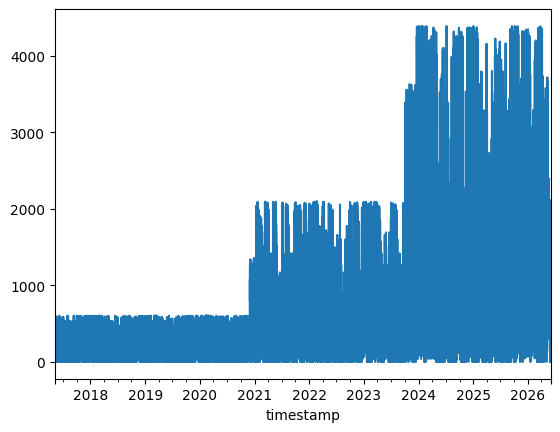

In [19]:
df_predicted["Total"].plot()

In [20]:
# Build a capacity timeline
df_farms = pd.DataFrame(wind_farms_metadata)
df_farms["commissioned"] = pd.to_datetime(df_farms["commissioned"], dayfirst=True)
df_farms["installed_capacity_mw"] = pd.to_numeric(df_farms["installed_capacity_mw"])

df_farms = df_farms.sort_values("commissioned")
df_farms["cumulative_capacity"] = df_farms["installed_capacity_mw"].cumsum()

# Sort by commission date and calculate cumulative capacity
df_farms = df_farms.sort_values("commissioned")
df_farms["cumulative_capacity"] = df_farms["installed_capacity_mw"].cumsum()


start_date = entsoe_timeseries_df.index.min()

# Filter farms commissioned before the start of the data
df_farms_filtered = df_farms[df_farms["commissioned"] >= start_date].copy()

# Recalculate cumulative capacity starting from whatever was already installed at start_date
baseline_capacity = df_farms[df_farms["commissioned"] < start_date]["installed_capacity_mw"].sum()
df_farms_filtered["cumulative_capacity"] = baseline_capacity + df_farms_filtered["installed_capacity_mw"].cumsum()

# Extend the step line
end_date = entsoe_timeseries_df.index.max()

max_capacity = df_farms_filtered["cumulative_capacity"].max()
commissioned_extended = pd.concat([pd.Series([start_date]), df_farms_filtered["commissioned"], pd.Series([end_date])])
capacity_extended = pd.concat([pd.Series([baseline_capacity]), df_farms_filtered["cumulative_capacity"], pd.Series([max_capacity])])

C:\Users\lackn\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\plotting\_matplotlib\core.py:997: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


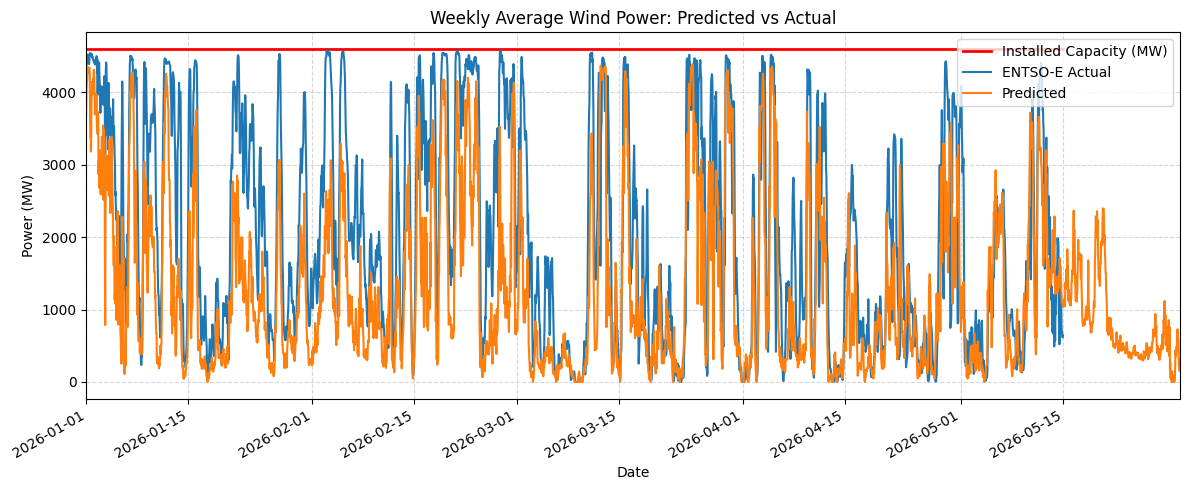

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

resample = "h"

ax.step(commissioned_extended, capacity_extended, where="post", color="red", linewidth=2, label="Installed Capacity (MW)")
entsoe_timeseries_df["Generation_MW"].resample(resample).mean().plot(ax=ax, label="ENTSO-E Actual")
df_predicted["Total"].resample(resample).mean().plot(ax=ax, label="Predicted")

for _, row in df_farms.iterrows():
    ax.annotate(row["name"],
                xy=(row["commissioned"], row["cumulative_capacity"]),
                xytext=(-10, 0),
                textcoords="offset points",
                fontsize=8,
                rotation=0,
                ha="right",
                va="center")

ax.set_title("Weekly Average Wind Power: Predicted vs Actual")
ax.set_xlabel("Date")
ax.set_ylabel("Power (MW)")
ax.set_xlim("2026-01-01", "2026-05-31")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Fitted parameters:
alpha=759.000, beta=1.779, gamma=0.858, delta=10.254


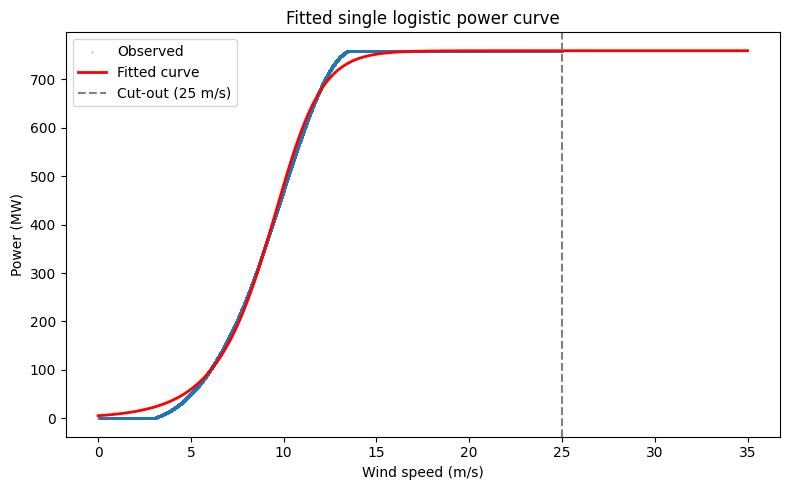

In [22]:
def single_logistic(v, alpha, beta, gamma, delta):
    return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)

def predict_power(wind_speed, popt, cut_in=3.0, cut_out=25.0):
    p = single_logistic(wind_speed, *popt)
    #p = np.where(wind_speed >= cut_out, 0, p)
    #p = np.where(wind_speed < cut_in, 0, p)
    #p = np.maximum(p, 0)
    return p

# --- prep data ---
fit_df = df[(df["Turn_off"] == 1)].copy()

v = fit_df["Scaled_Windspeed"].values
p = fit_df["Power"].values

# --- fit ---
p0 = [
    p.max(),  # alpha: rated power
    1.0,      # beta
    1.0,      # gamma: steepness
    10.0      # delta: inflection point
]

popt, pcov = curve_fit(
    single_logistic,
    v, p,
    p0=p0,
    bounds=(
        [0,    0.01, 0,    0  ],
        [p.max()*1, 10,   10,   30]
    ),
    maxfev=10000
)

print("Fitted parameters:")
print(f"alpha={popt[0]:.3f}, beta={popt[1]:.3f}, gamma={popt[2]:.3f}, delta={popt[3]:.3f}")

# --- plot ---
v_range = np.linspace(0, 35, 500)
p_fitted = predict_power(v_range, popt)

plt.figure(figsize=(8, 5))
plt.scatter(v, p, s=1, alpha=0.2, label="Observed")
plt.plot(v_range, p_fitted, color="red", linewidth=2, label="Fitted curve")
plt.axvline(25, color="gray", linestyle="--", label="Cut-out (25 m/s)")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power (MW)")
plt.title("Fitted single logistic power curve")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# --- prep data ---
fit_df = df[(df["Turn_off"] == 1) & (df["Scaled_Windspeed"] > 0)].copy()

# bin by wind speed
fit_df["v_bin"] = fit_df["Scaled_Windspeed"].round(1)
binned = fit_df.groupby("v_bin")["Power"].mean().reset_index()

# --- cut-in: lowest wind speed where power becomes non-zero ---
cut_in_speed = binned.loc[binned["Power"] > 1, "v_bin"].min()

# --- rated: lowest wind speed where power reaches max and stays there ---
p_max = binned["Power"].max()
rated_speed = binned.loc[binned["Power"] >= 0.99 * p_max, "v_bin"].min()

print(f"Cut-in wind speed: {cut_in_speed:.2f} m/s")
print(f"Rated wind speed: {rated_speed:.2f} m/s")
print(f"Max observed power: {p_max:.2f} MW")

Cut-in wind speed: 3.10 m/s
Rated wind speed: 13.20 m/s
Max observed power: 759.00 MW


Fitted parameters:
alpha=866.451, beta=0.705, gamma=0.498, delta=8.701


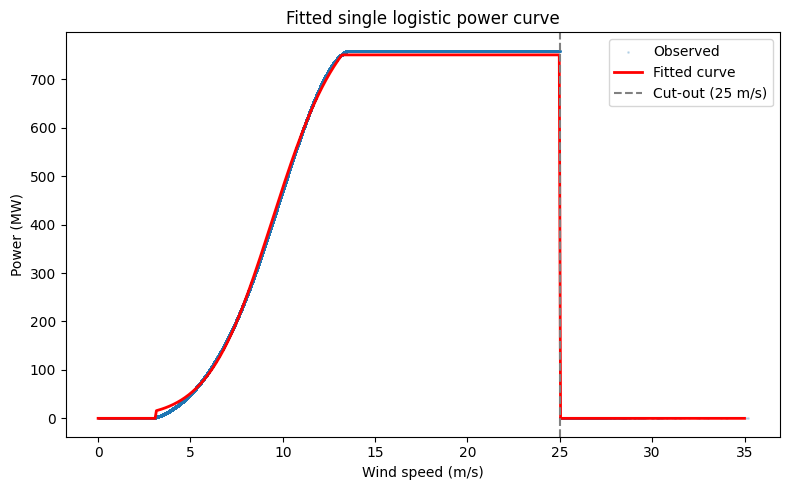

In [24]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def single_logistic(v, alpha, beta, gamma, delta):
    return alpha / (1 + np.exp(-gamma * (v - delta))) ** (1 / beta)

def predict_power(wind_speed, popt, cut_in=3.1, cut_out=13.2, turn_off = 25):
    p = single_logistic(wind_speed, *popt)
    p = np.where(wind_speed >= cut_out, single_logistic(cut_out, *popt), p)
    p = np.where(wind_speed >= turn_off, 0, p)
    p = np.where(wind_speed < cut_in, 0, p)
    p = np.maximum(p, 0)
    return p

# --- prep data ---
fit_df = df[(df["Turn_off"] == 1) & (df["Scaled_Windspeed"] >= 2) & (df["Scaled_Windspeed"] <= 14)].copy()

v = fit_df["Scaled_Windspeed"].values
p = fit_df["Power"].values

# --- fit ---
p0 = [
    p.max(),  # alpha: rated power
    1.0,      # beta
    1.0,      # gamma: steepness
    10.0      # delta: inflection point
]

popt, pcov = curve_fit(
    single_logistic,
    v, p,
    p0=p0,
    bounds=(
        [0,    0.01, 0,    0  ],
        [np.inf, 10,   10,   30]
    ),
    maxfev=10000
)

print("Fitted parameters:")
print(f"alpha={popt[0]:.3f}, beta={popt[1]:.3f}, gamma={popt[2]:.3f}, delta={popt[3]:.3f}")

# --- plot ---
v_range = np.linspace(0, 35, 500)
p_fitted = predict_power(v_range, popt)

plt.figure(figsize=(8, 5))
plt.scatter(df["Scaled_Windspeed"].values, df["Power"].values, s=1, alpha=0.2, label="Observed")
plt.plot(v_range, p_fitted, color="red", linewidth=2, label="Fitted curve")
plt.axvline(25, color="gray", linestyle="--", label="Cut-out (25 m/s)")
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Power (MW)")
plt.title("Fitted single logistic power curve")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\lackn\AppData\Local\Temp\ipykernel_23328\3374755428.py:11: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


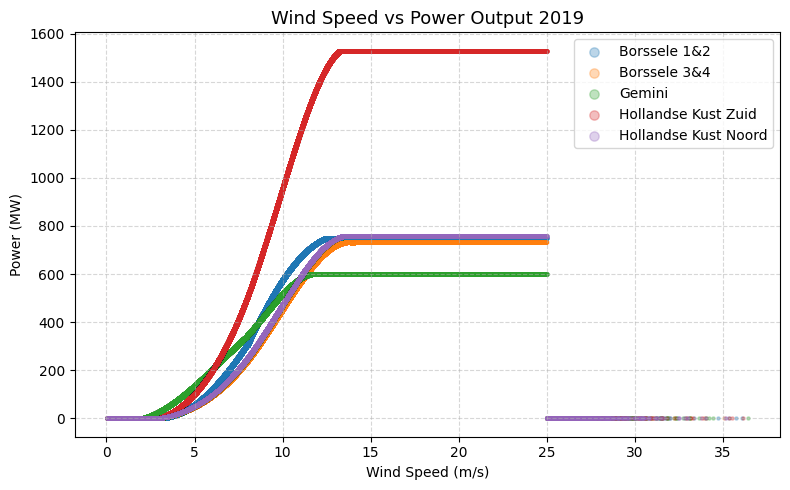

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

for label, df in datasets.items():
    ax.scatter(df['Scaled_Windspeed'], df['Power'], alpha=0.3, s=5, label=label)

ax.set_title('Wind Speed vs Power Output 2019', fontsize=13)
ax.set_xlabel('Wind Speed (m/s)')
ax.set_ylabel('Power (MW)')
ax.legend(markerscale=3)   # markerscale makes the tiny dots visible in the legend
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()